# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score

# just setting some default plot size
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("libraries imported")


libraries imported


## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/manvadityasinghk/country-data-set/Country-data.csv')
dd = pd.read_csv('/kaggle/input/datasets/manvadityasinghk/country-data-set/data-dictionary.csv')

print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [4]:
# checking what each column means
print(dd.to_string(index=False))


Column Name                                                                                                      Description
    country                                                                                              Name of the country
 child_mort                                                      Death of children under 5 years of age per 1000 live births
    exports                                    Exports of goods and services per capita. Given as %age of the GDP per capita
     health                                                Total health spending per capita. Given as %age of GDP per capita
    imports                                    Imports of goods and services per capita. Given as %age of the GDP per capita
     Income                                                                                            Net income per person
  Inflation                                                       The measurement of the annual growth rate of the Total GDP


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [5]:
# basic stats
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [6]:
# checking for null values
print("null values in each column:")
print(df.isnull().sum())
print()
print("total nulls:", df.isnull().sum().sum())


null values in each column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

total nulls: 0


## 7) Exploratory Data Analysis

In [7]:
# checking data types
print(df.dtypes)

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


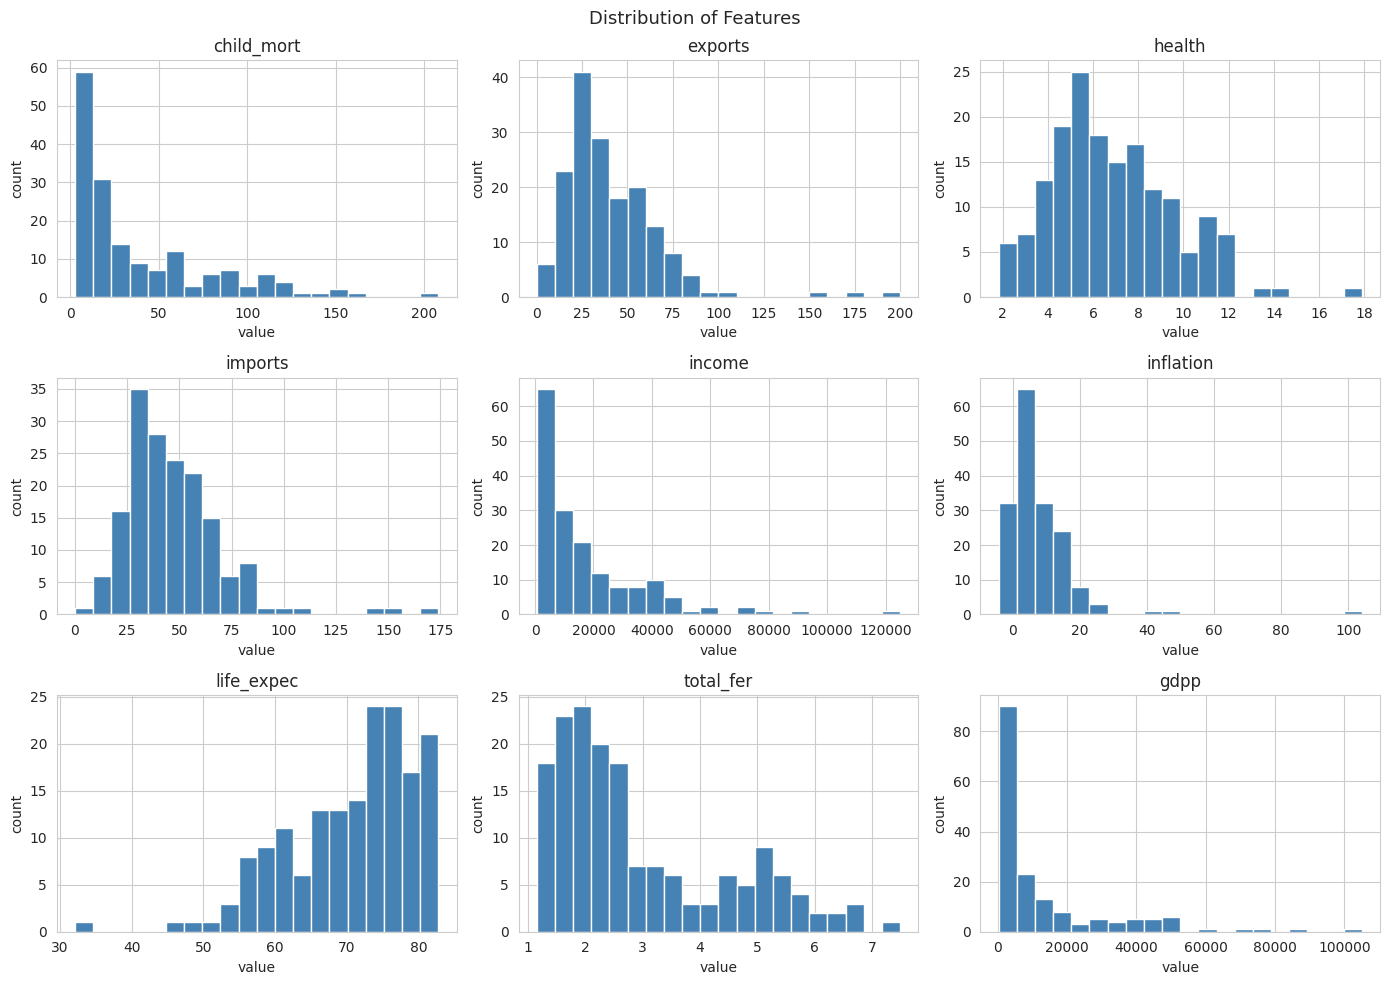

In [8]:
# plotting distribution of each feature
cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('value')
    axes[i].set_ylabel('count')

plt.suptitle('Distribution of Features', fontsize=13)
plt.tight_layout()
plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

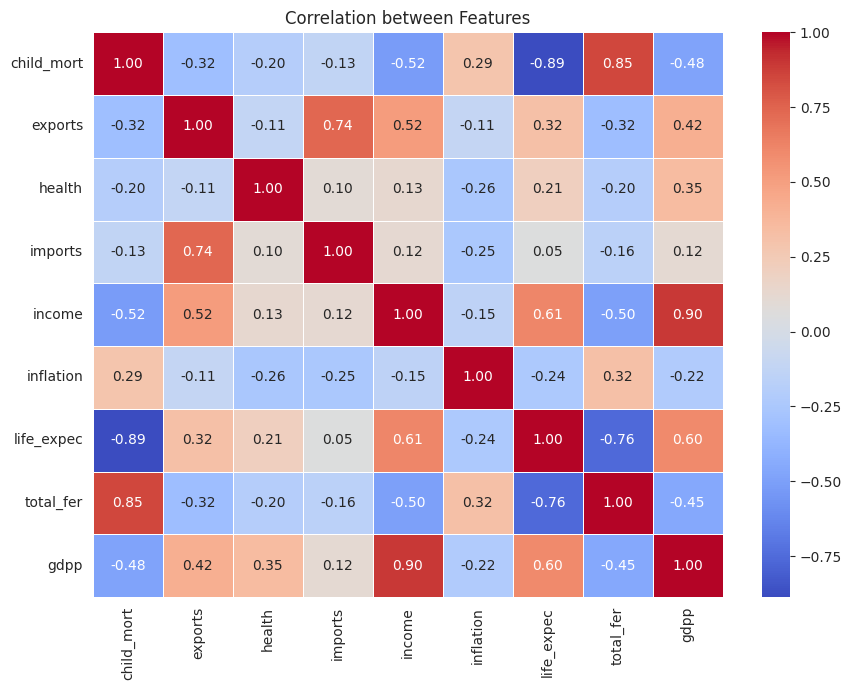

In [9]:
# correlation heatmap
corr = df[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4)
plt.title('Correlation between Features')
plt.tight_layout()
plt.show()


In [10]:
# saving country names separately since its not needed for clustering
countries = df['country'].values

# dropping country column
data = df.drop('country', axis=1)

print("feature columns:", list(data.columns))
print("rows:", len(data))


feature columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
rows: 167


In [11]:
# using a pipeline to scale the data - cleaner approach
# then also making a 2d version with pca for visualization later

scale_pipe = Pipeline([
    ('scaler', StandardScaler())
])

scaled_data = scale_pipe.fit_transform(data)

print("scaled data shape:", scaled_data.shape)


scaled data shape: (167, 9)


In [12]:
# pca for 2d visualization only
pca_2d = PCA(n_components=2, random_state=42)
data_2d = pca_2d.fit_transform(scaled_data)

print("2d data shape:", data_2d.shape)
print("variance explained by 2 components:", round(sum(pca_2d.explained_variance_ratio_)*100, 2), "%")


2d data shape: (167, 2)
variance explained by 2 components: 63.13 %


In [13]:
# saving country names separately since its not needed for clustering
countries = df['country'].values

# dropping country column
data = df.drop('country', axis=1)

print("feature columns:", list(data.columns))
print("rows:", len(data))


feature columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
rows: 167


## Step 5 - Principal Component Analysis (PCA)

In [14]:
# fitting pca on all components to check variance
pca_full = PCA(random_state=42)
pca_full.fit(scaled_data)

var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

print("explained variance per component:")
for i, (v, c) in enumerate(zip(var_ratio, cum_var)):
    print(f"  PC{i+1}: {round(v*100, 2)}%  (cumulative: {round(c*100, 2)}%)")


explained variance per component:
  PC1: 45.95%  (cumulative: 45.95%)
  PC2: 17.18%  (cumulative: 63.13%)
  PC3: 13.0%  (cumulative: 76.14%)
  PC4: 11.05%  (cumulative: 87.19%)
  PC5: 7.34%  (cumulative: 94.53%)
  PC6: 2.48%  (cumulative: 97.02%)
  PC7: 1.26%  (cumulative: 98.28%)
  PC8: 0.98%  (cumulative: 99.26%)
  PC9: 0.74%  (cumulative: 100.0%)


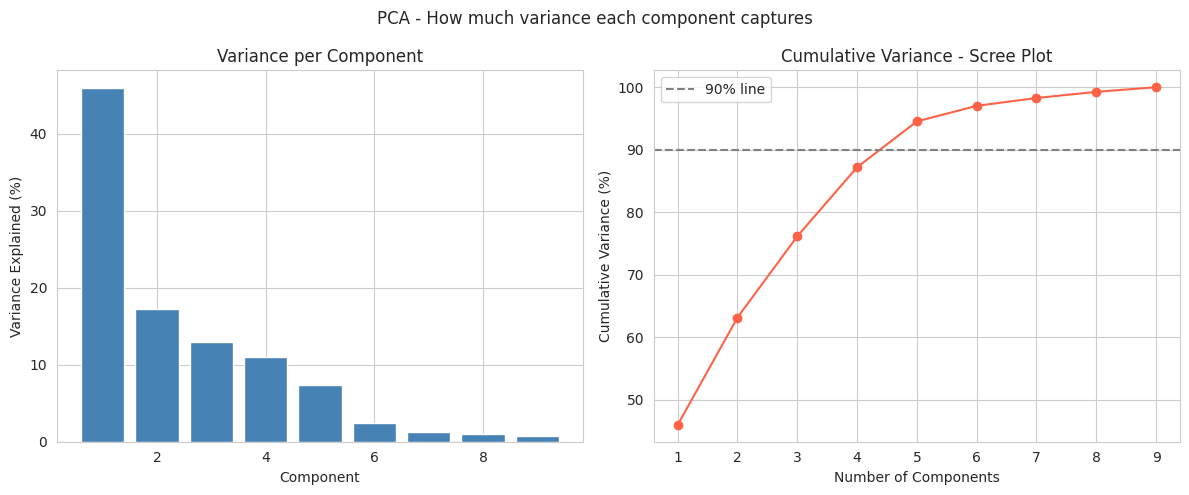

In [15]:
# scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

components = list(range(1, len(var_ratio)+1))

axes[0].bar(components, var_ratio * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Variance per Component')

axes[1].plot(components, cum_var * 100, marker='o', color='tomato')
axes[1].axhline(90, color='gray', linestyle='--', label='90% line')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance - Scree Plot')
axes[1].legend()

plt.suptitle('PCA - How much variance each component captures', fontsize=12)
plt.tight_layout()
plt.show()


## 10) Train K-Means

In [16]:
# checking different values of k
k_range = range(2, 11)
wcss = []
sil = []
db = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(scaled_data, km.labels_))
    db.append(davies_bouldin_score(scaled_data, km.labels_))

print("done evaluating clusters for k = 2 to 10")


done evaluating clusters for k = 2 to 10


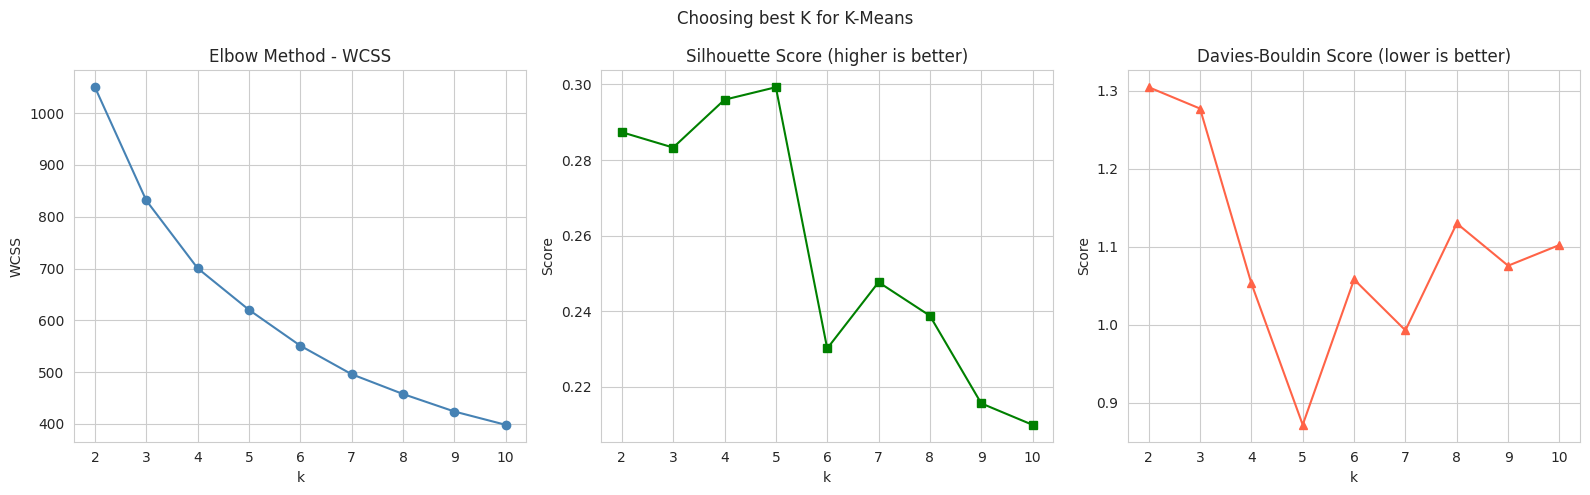

In [17]:
# plotting elbow + silhouette + db score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(list(k_range), wcss, marker='o', color='steelblue')
axes[0].set_title('Elbow Method - WCSS')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(k_range), sil, marker='s', color='green')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

axes[2].plot(list(k_range), db, marker='^', color='tomato')
axes[2].set_title('Davies-Bouldin Score (lower is better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')

plt.suptitle('Choosing best K for K-Means', fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# from the plots k=3 looks like the best choice
best_k = 3
best_sil_idx = sil.index(max(sil))
print("best silhouette at k =", list(k_range)[best_sil_idx], "score:", round(max(sil), 4))
print("going with k =", best_k, "based on elbow + silhouette")


best silhouette at k = 5 score: 0.2993
going with k = 3 based on elbow + silhouette


In [19]:
# fitting final kmeans model
km_model = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)
km_model.fit(scaled_data)

km_labels = km_model.labels_
df['cluster'] = km_labels

print("silhouette score:", round(silhouette_score(scaled_data, km_labels), 4))
print()
print("countries in each cluster:")
print(df['cluster'].value_counts().sort_index())


silhouette score: 0.2833

countries in each cluster:
cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [20]:
# average values per cluster
cluster_avg = df.groupby('cluster')[cols].mean().round(2)
print("cluster averages:")
cluster_avg


cluster averages:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Step 7 - Visualizing Clusters with PCA

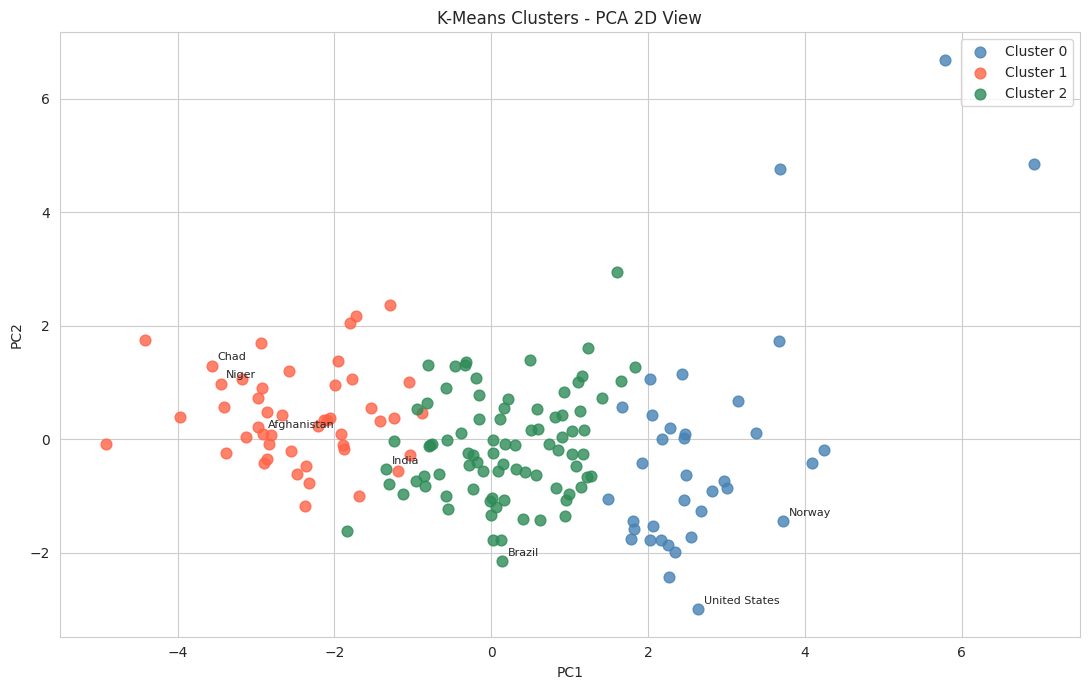

In [21]:
colors = ['steelblue', 'tomato', 'seagreen']
labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, ax = plt.subplots(figsize=(11, 7))

for cl in range(3):
    mask = km_labels == cl
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               c=colors[cl], label=labels_map[cl], s=60, alpha=0.8)

# highlighting some countries
highlight = ['Afghanistan', 'Niger', 'Chad', 'United States', 'Norway', 'India', 'Brazil']
for i, name in enumerate(countries):
    if name in highlight:
        ax.annotate(name, (data_2d[i, 0], data_2d[i, 1]), fontsize=8,
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clusters - PCA 2D View')
ax.legend()
plt.tight_layout()
plt.show()


## Step 8 - DBSCAN Clustering

In [22]:
# trying dbscan as another clustering method
db_model = DBSCAN(eps=2.5, min_samples=4)
db_model.fit(scaled_data)

db_labels = db_model.labels_

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

df['db_cluster'] = db_labels

print("clusters found by dbscan:", n_clusters)
print("noise/outlier points:", n_noise)
print()
print("label distribution:")
print(pd.Series(db_labels).value_counts().sort_index())


clusters found by dbscan: 1
noise/outlier points: 6

label distribution:
-1      6
 0    161
Name: count, dtype: int64


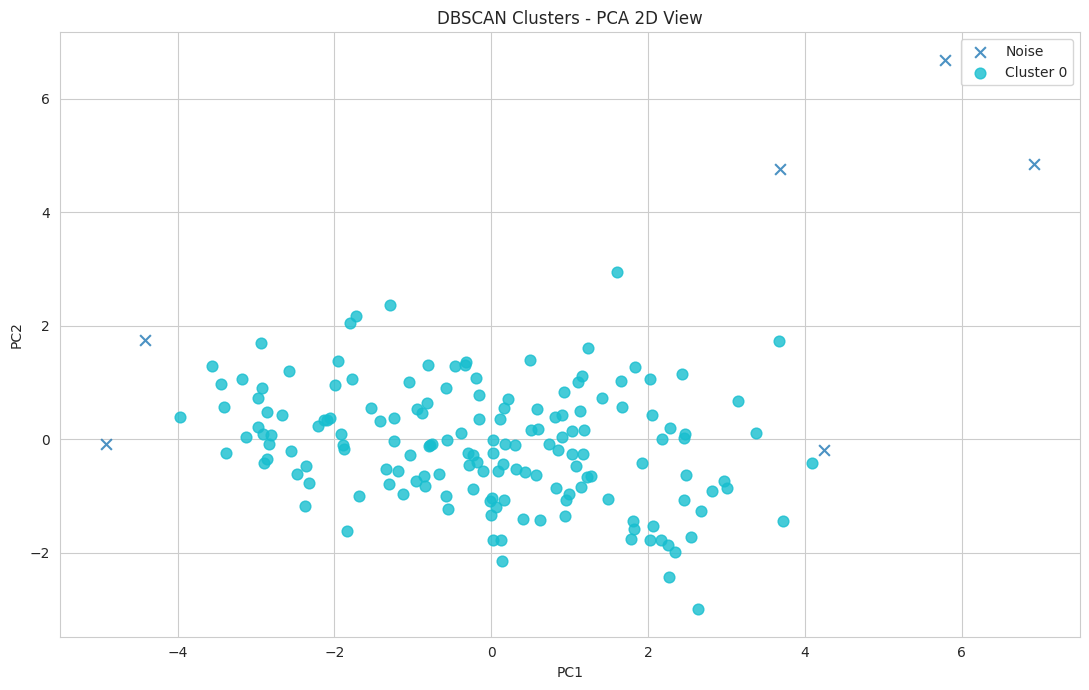

In [23]:
# visualizing dbscan clusters
unique_labels = sorted(set(db_labels))
cmap = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, ax = plt.subplots(figsize=(11, 7))

for lbl, col in zip(unique_labels, cmap):
    mask = db_labels == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    mk = 'x' if lbl == -1 else 'o'
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               c=[col], label=name, marker=mk, s=60, alpha=0.8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('DBSCAN Clusters - PCA 2D View')
ax.legend()
plt.tight_layout()
plt.show()


## Step 9 - Country Insights and Recommendations

In [24]:
# looking at cluster averages for key indicators
summary = df.groupby('cluster')[['child_mort', 'life_expec', 'income', 'gdpp', 'health']].mean().round(2)
print(summary)


         child_mort  life_expec    income      gdpp  health
cluster                                                    
0              5.00       80.13  45672.22  42494.44    8.81
1             92.96       59.19   3942.40   1922.38    6.39
2             21.93       72.81  12305.60   6486.45    6.20


In [25]:
# scoring clusters by need
# higher child_mort = worse, lower gdpp = worse, lower life_expec = worse
need = df.groupby('cluster')[['child_mort', 'gdpp', 'life_expec']].mean()

need['score'] = (
    need['child_mort'].rank(ascending=False) +
    need['gdpp'].rank(ascending=True) +
    need['life_expec'].rank(ascending=True)
)

worst_cluster = need['score'].idxmax()
print("cluster with highest need:", worst_cluster)
print()
print(need)


cluster with highest need: 0

         child_mort          gdpp  life_expec  score
cluster                                             
0          5.000000  42494.444444   80.127778    9.0
1         92.961702   1922.382979   59.187234    3.0
2         21.927381   6486.452381   72.814286    6.0


In [26]:
# countries in the worst cluster
needy = df[df['cluster'] == worst_cluster].copy()
needy_sorted = needy.sort_values(['child_mort', 'gdpp'], ascending=[False, True])
needy_sorted = needy_sorted[['country', 'child_mort', 'life_expec', 'income', 'gdpp']].reset_index(drop=True)

print(f"total countries in highest-need cluster: {len(needy_sorted)}")
print()
print(needy_sorted.to_string(index=False))


total countries in highest-need cluster: 36

             country  child_mort  life_expec  income   gdpp
              Kuwait        10.8        78.2   75200  38500
              Brunei        10.5        77.1   80600  35300
               Qatar         9.0        79.5  125000  70300
             Bahrain         8.6        76.0   41100  20700
United Arab Emirates         8.6        76.5   57600  35000
       United States         7.3        78.7   49400  48400
     Slovak Republic         7.0        75.5   25200  16600
               Malta         6.8        80.3   28300  21100
         New Zealand         6.2        80.9   32300  33700
              Canada         5.6        81.3   40700  47400
      United Kingdom         5.2        80.3   36200  38900
           Australia         4.8        82.0   41400  51900
              Israel         4.6        81.4   29600  30600
             Belgium         4.5        80.0   41100  44400
         Netherlands         4.5        80.7   45500  5

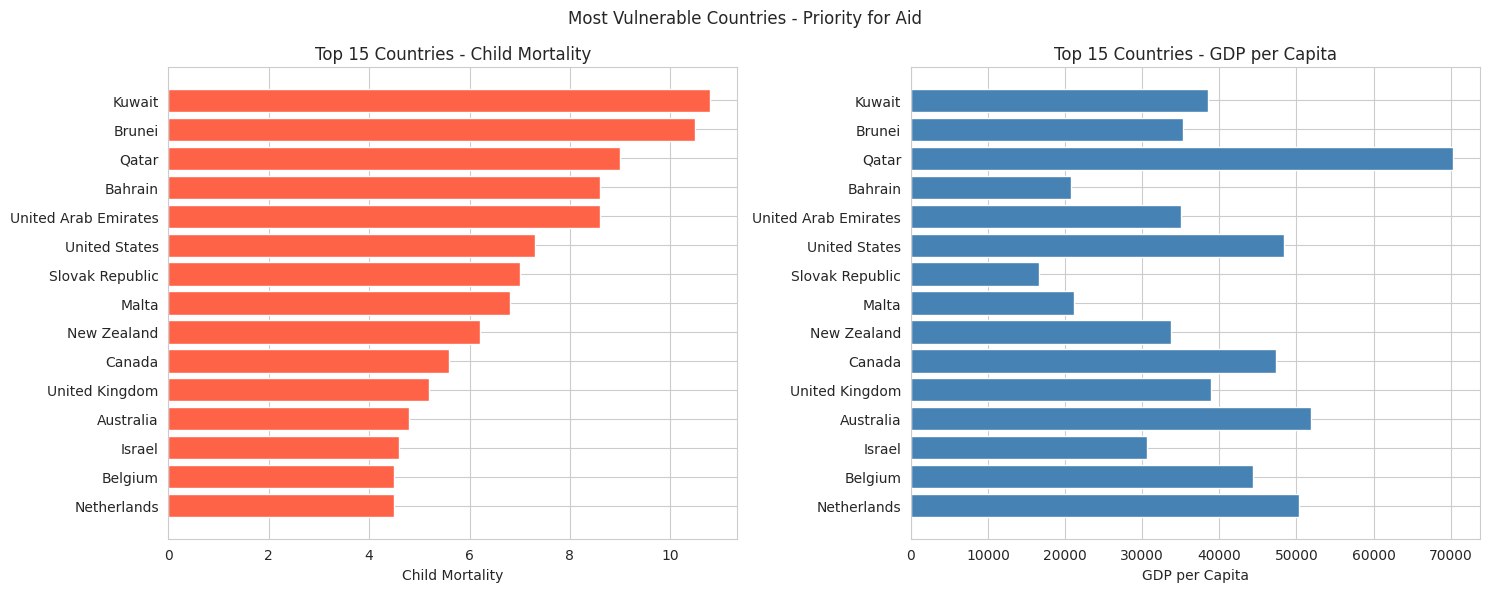

In [27]:
# bar charts for top 15 most vulnerable
top15 = needy_sorted.head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top15['country'][::-1], top15['child_mort'][::-1], color='tomato')
axes[0].set_xlabel('Child Mortality')
axes[0].set_title('Top 15 Countries - Child Mortality')

axes[1].barh(top15['country'][::-1], top15['gdpp'][::-1], color='steelblue')
axes[1].set_xlabel('GDP per Capita')
axes[1].set_title('Top 15 Countries - GDP per Capita')

plt.suptitle('Most Vulnerable Countries - Priority for Aid', fontsize=12)
plt.tight_layout()
plt.show()


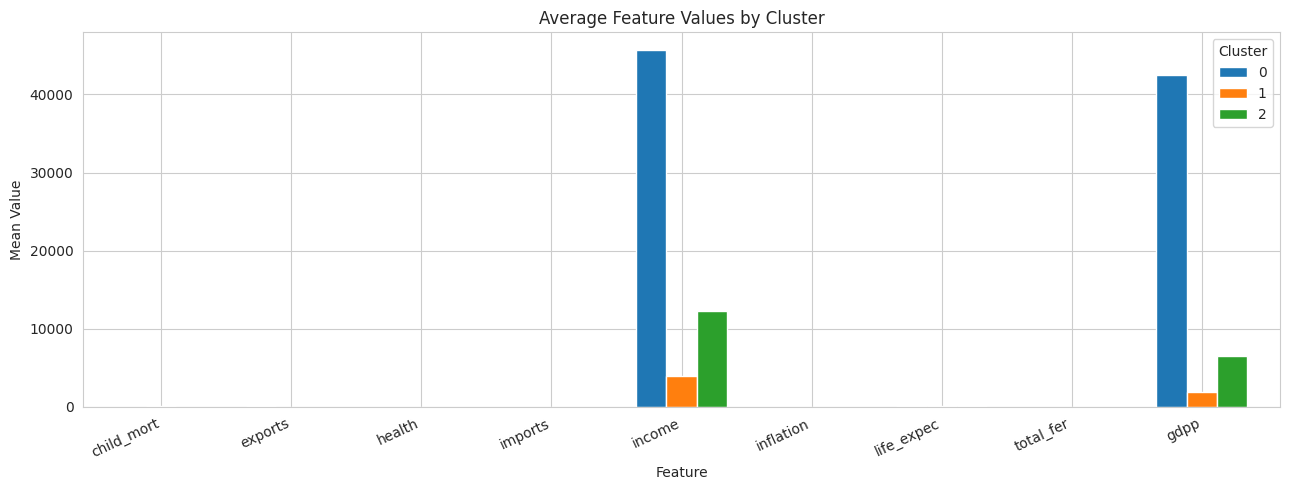

In [28]:
# comparing all clusters on mean feature values
compare = df.groupby('cluster')[cols].mean()

compare.T.plot(kind='bar', figsize=(13, 5), width=0.7)
plt.title('Average Feature Values by Cluster')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?
